# **Importing the Libraries:**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Reading the dataset:**

In [93]:
df=pd.read_csv('student_habits_cleaned.csv')
df=df.drop(columns=['total_hours','total_screen_time'])

# **Data Overview:**

In [94]:
df.shape

(1000, 16)

In [3]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score,total_screen_time,total_hours
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2,2.3,10.3
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0,5.1,16.6
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3,4.4,13.8
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8,4.9,15.1
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4,4.9,14.8


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       1000 non-null   object 
 12  internet_quality               1000 non-null   ob

In [9]:
df.dtypes

,0
student_id,object
age,int64
gender,object
study_hours_per_day,float64
social_media_hours,float64
netflix_hours,float64
part_time_job,object
attendance_percentage,float64
sleep_hours,float64
diet_quality,object


In [4]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score,total_screen_time,total_hours
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500,4.325200,14.345400
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564,1.599808,2.478395
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000,0.200000,6.800000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000,3.300000,12.600000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000,4.400000,14.300000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000,5.400000,16.025000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000,10.100000,21.500000


In [10]:
df.columns

Index(['student_id', 'age', 'gender', 'study_hours_per_day',
       'social_media_hours', 'netflix_hours', 'part_time_job',
       'attendance_percentage', 'sleep_hours', 'diet_quality',
       'exercise_frequency', 'parental_education_level', 'internet_quality',
       'mental_health_rating', 'extracurricular_participation', 'exam_score',
       'total_screen_time', 'total_hours'],
      dtype='object')

In [11]:
def data_info(data):

    """
    This function returns a DataFrame containing the summary information for each column
    """

    Names=[col for col in data]
    data_types=[data[col].dtype for col in data.columns]
    top_10_unique_values=[data[col].value_counts().head(10).index.to_list() for col in data.columns]
    nunique_values=[data[col].nunique() for col in data.columns]
    nulls=[data[col].isnull().sum() for col in data.columns]
    percent_of_Nulls= [data[col].isnull().sum()/len(data)*100 for col in data.columns]


    info_df=pd.DataFrame({'Name':Names,
                          'Data_Type':data_types,
                          'Top_10_Unique_Values':top_10_unique_values,
                          'Nunique_Values':nunique_values,
                          'Nulls':nulls,
                          'Percent_of_Nulls':percent_of_Nulls,
                          })
    return info_df

In [12]:
data_info(df)

,Name,Data_Type,Top_10_Unique_Values,Nunique_Values,Nulls,Percent_of_Nulls
0,student_id,object,"[S1999, S1000, S1001, S1002, S1003, S1004, S10...",1000,0,0.0
1,age,int64,"[20, 24, 17, 21, 23, 18, 19, 22]",8,0,0.0
2,gender,object,"[Female, Male, Other]",3,0,0.0
3,study_hours_per_day,float64,"[3.5, 3.2, 4.3, 3.3, 3.8, 4.1, 3.6, 3.0, 3.9, ...",78,0,0.0
4,social_media_hours,float64,"[3.1, 3.2, 2.9, 2.2, 2.1, 3.0, 2.4, 2.3, 1.9, ...",60,0,0.0
5,netflix_hours,float64,"[0.0, 2.0, 1.7, 1.4, 1.6, 2.3, 2.2, 2.4, 0.9, ...",51,0,0.0
6,part_time_job,object,"[No, Yes]",2,0,0.0
7,attendance_percentage,float64,"[100.0, 85.8, 85.3, 84.8, 83.2, 79.9, 81.7, 85...",320,0,0.0
8,sleep_hours,float64,"[6.5, 6.1, 6.2, 6.7, 5.5, 7.1, 7.0, 6.6, 6.3, ...",68,0,0.0
9,diet_quality,object,"[Fair, Good, Poor]",3,0,0.0


# **Visualizing the data:**

**Distribution of the exam score:**

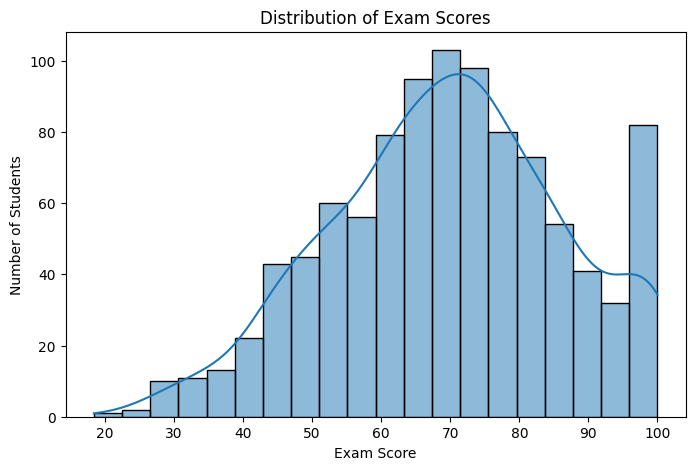

'the exam score is nearly a normal distribution !'

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x='exam_score',
    bins=20,
    kde=True
)

plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Number of Students')

plt.show()

"the exam score is nearly a normal distribution !"

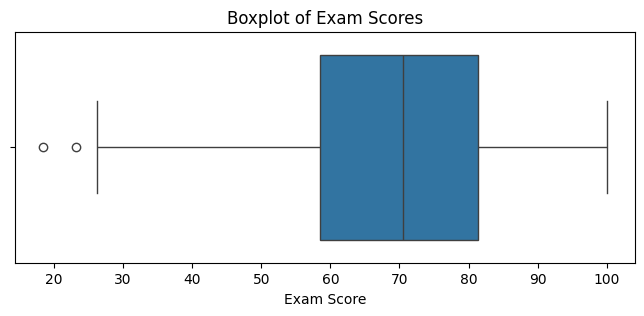

In [16]:
plt.figure(figsize=(8, 3))

sns.boxplot(
    data=df,
    x='exam_score'
)

plt.title('Boxplot of Exam Scores')
plt.xlabel('Exam Score')

plt.show()

**How does the average exam performance change across age :**

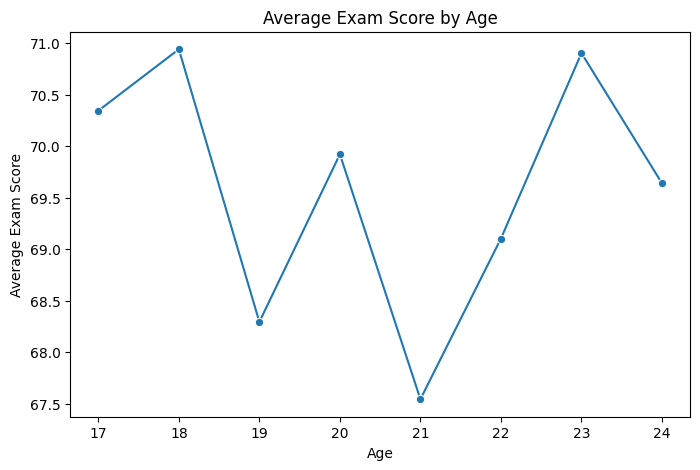

In [36]:
age_performance = df.groupby('age')['exam_score'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(
    data=age_performance,
    x='age',
    y='exam_score',
    marker='o'
)

plt.title('Average Exam Score by Age')
plt.xlabel('Age')
plt.ylabel('Average Exam Score')
plt.show()

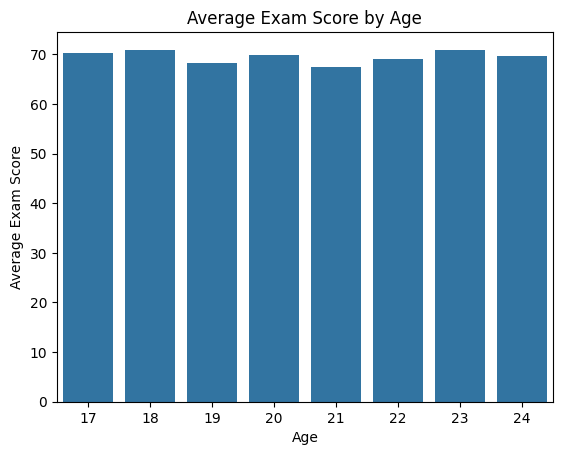

In [37]:
sns.barplot(
    data=age_performance,
    x='age',
    y='exam_score',
)

plt.title('Average Exam Score by Age')
plt.xlabel('Age')
plt.ylabel('Average Exam Score')
plt.show()

**now the for the most important feature (study_hours):**

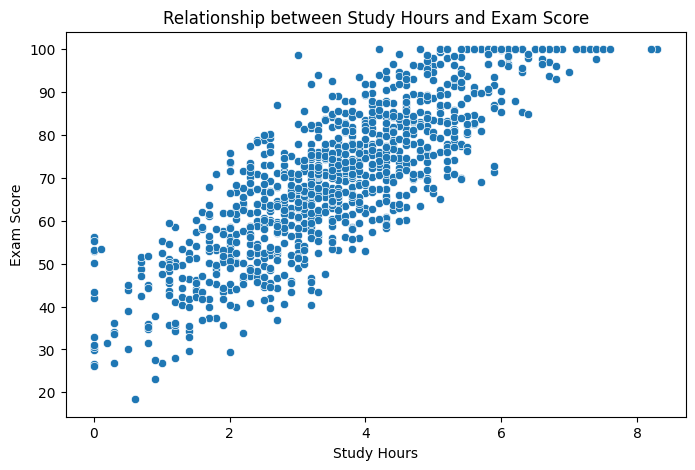

" there's obviously a positive very strong near perfect linear relationship\n    between the study hours and the final exam score as As expected "

In [42]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='study_hours_per_day',
    y='exam_score',
)

plt.title('Relationship between Study Hours and Exam Score')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.show()

"""
the dataset obviously a positive very strong near perfect linear relationship
between the study hours and the final exam score as As expected !
     """

In [44]:
correlation = df['study_hours_per_day'].corr(df['exam_score'])

print(correlation)
" nearly 0.83 that means its a very strong correlation !! "

0.825418509396044


' nearly 0.83 that means its a very strong correlation !! '

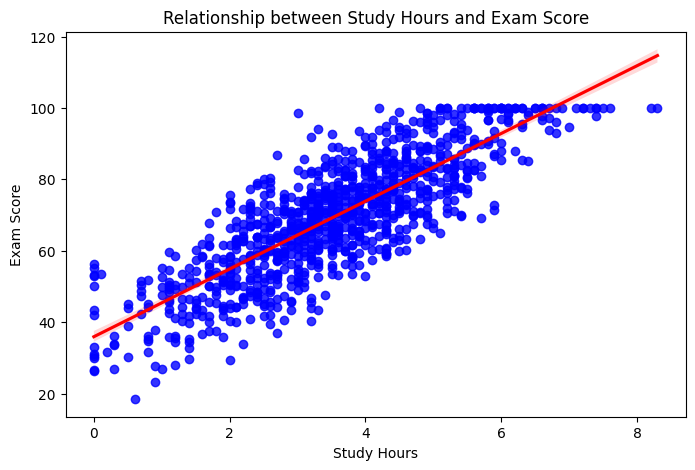

In [45]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x='study_hours_per_day',
    y='exam_score',
    scatter_kws={'color': 'blue'},
    line_kws={'color': 'red'}
)

plt.title('Relationship between Study Hours and Exam Score')
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.show()
"""
that clearly shows that we can draw a line that fits most of the data points , it
confirms more that the study hours correlates with the exam score almost linearly !!
"""

**getting the relationship between the attendance and the score:**

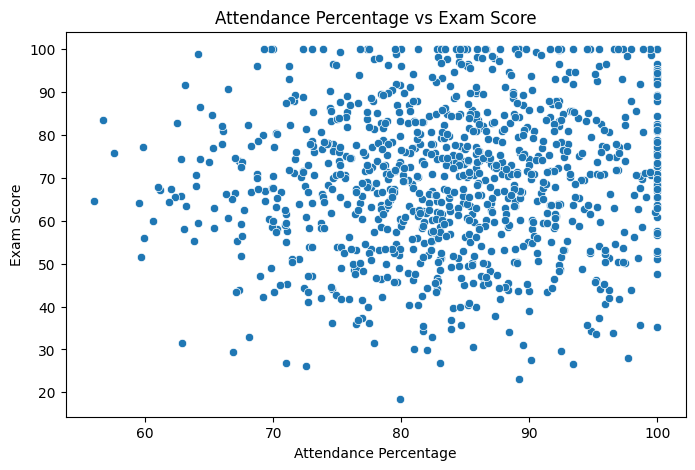

In [46]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='attendance_percentage',
    y='exam_score'
)

plt.title('Attendance Percentage vs Exam Score')
plt.xlabel('Attendance Percentage')
plt.ylabel('Exam Score')
plt.show()
"""
unlike the expected!
the attendance percentage does not correlate with the exam score at all !!
the data points are completely scattered and there is no clear pattern.
"""

In [47]:
attendance_corr=df['attendance_percentage'].corr(df['exam_score'])
print(attendance_corr)
" 0.09 correlation assures that Attendance has almost no linear relationship with exam score in this dataset ."

0.08983560176992733


In [ ]:
"""
Study hours showed a very strong positive linear relationship (r ≈ 0.83)
with exam score, while attendance percentage showed almost
no linear relationship with exam score (r ≈ 0.09).
"""

**getting the relationship between sleep_hours & exam score:**

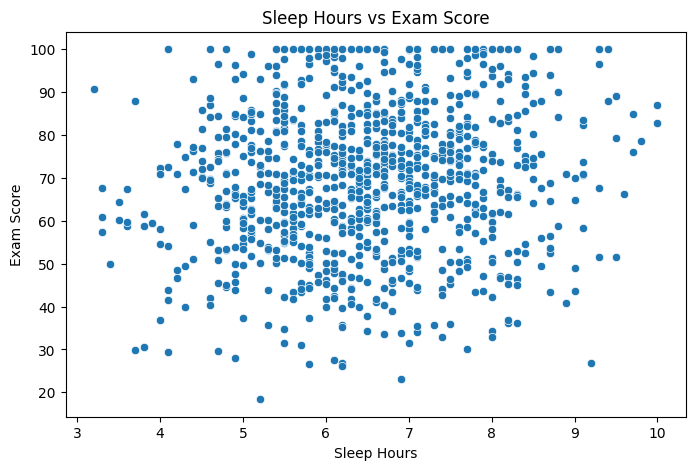

In [48]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x='sleep_hours',
    y='exam_score'
)

plt.title('Sleep Hours vs Exam Score')
plt.xlabel('Sleep Hours')
plt.ylabel('Exam Score')
plt.show()

In [50]:
sleep_corr=df['sleep_hours'].corr(df['exam_score'])
print(sleep_corr)

0.12168291063767979


**Getting the relationship between social hours & exam score:**

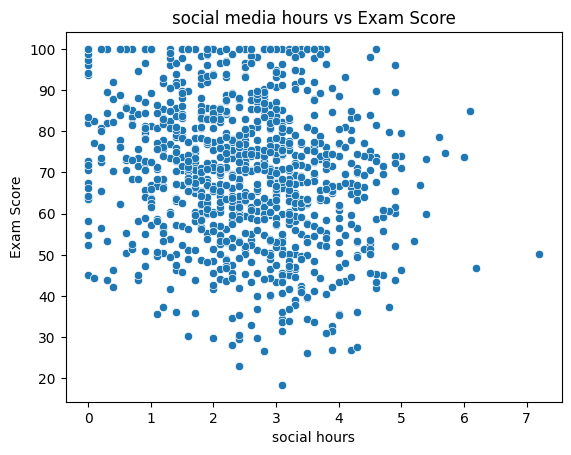

In [54]:
sns.scatterplot(
    data=df,
    x='social_media_hours',
    y='exam_score'
)

plt.title('social media hours vs Exam Score')
plt.xlabel('social hours')
plt.ylabel('Exam Score')
plt.show()

In [55]:
print(df['social_media_hours'].corr(df['exam_score']))

-0.16673288510861664


**Getting the relationship between netflix hours & exam score:**

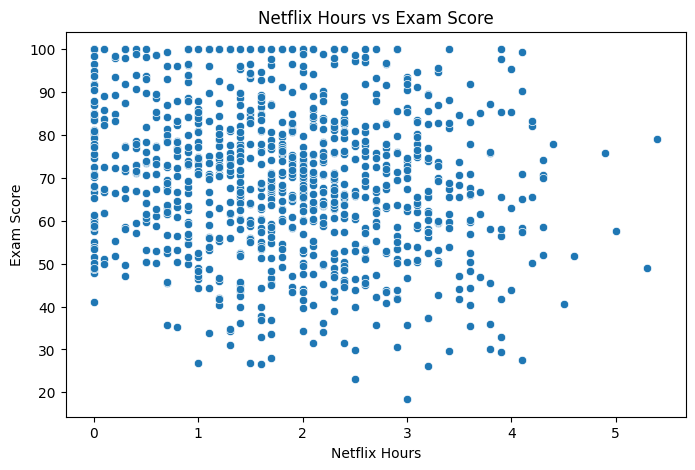

In [59]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='netflix_hours',
    y='exam_score'
)

plt.title('Netflix Hours vs Exam Score')
plt.xlabel('Netflix Hours')
plt.ylabel('Exam Score')
plt.show()

"""
the data is scattered and theres no fixed linear relationship between them , the dataset
initially the scatterplot shows that the relation appears to be a negative weak correlation
"""

In [58]:
print(df['netflix_hours'].corr(df['exam_score']))
" r=-0.1717 that imply theres a weak negative relationship between the netflix hours and the exam score. "

-0.17177923845531579


**Relation between exercise_frequency and the exam score:**

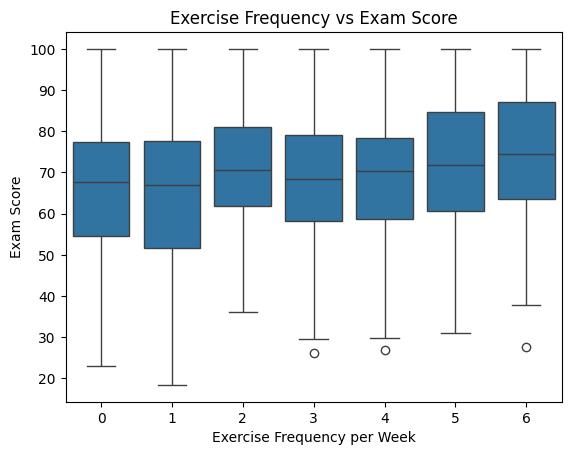

In [65]:
exercise_performance = df.groupby('exercise_frequency')['exam_score'].mean().reset_index()
sns.boxplot(
    data=df,
    x='exercise_frequency',
    y='exam_score'
)

plt.title('Exercise Frequency vs Exam Score')
plt.xlabel('Exercise Frequency per Week')
plt.ylabel('Exam Score')
plt.show()

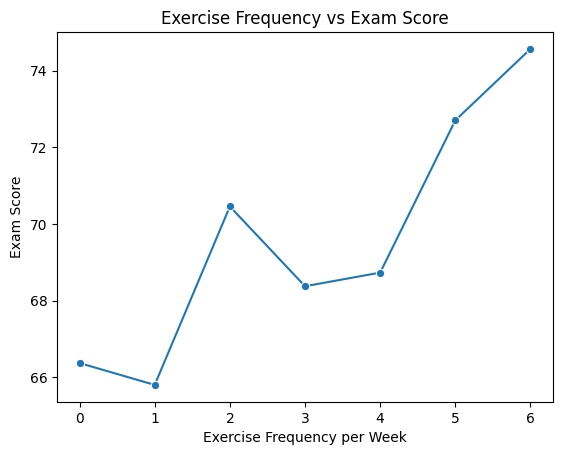

In [64]:

sns.lineplot(
    data=exercise_performance,
    x='exercise_frequency',
    y='exam_score',
    marker='o'

)

plt.title('Exercise Frequency vs Exam Score')
plt.xlabel('Exercise Frequency per Week')
plt.ylabel('Exam Score')
plt.show()

In [ ]:
"""
There is no clear monotonic relationship between exercise frequency and exam score.
    The average score goes up and down irregularly.
                                                   """

**Mental health relation with the exam score:**

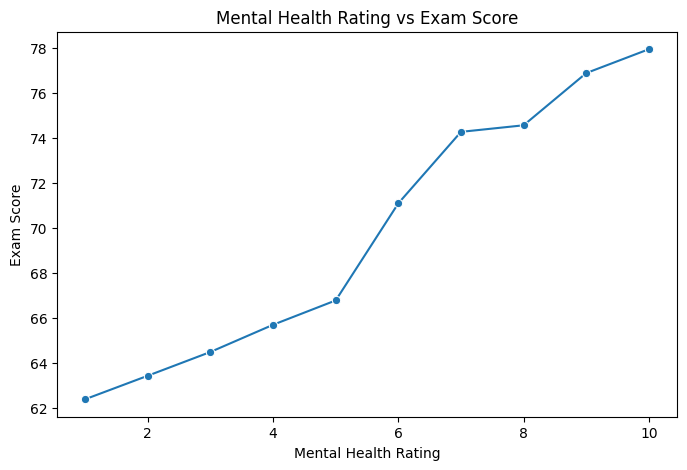

In [67]:
mental_health_performance = (
    df.groupby('mental_health_rating')['exam_score']
      .mean()
      .reset_index()
)
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=mental_health_performance,
    x='mental_health_rating',
    y='exam_score',
    marker='o'
    )


plt.title('Mental Health Rating vs Exam Score')
plt.xlabel('Mental Health Rating')
plt.ylabel('Exam Score')
plt.show()

"""
yes the relationship may nit be a perfect line but its a function that's increasing on it's domain
that clears the dataset shows a nearly moderate positive correlation between the mental health and the examscore .
"""

In [69]:
r = df['mental_health_rating'].corr(df['exam_score'])
print(r)
" r= 0.3215 that means there's a weak near moderate correlation between the mental health and the examscore ."

0.3215229306551462


# **Categorical data:**

**the relation between the diet quality and the exam score:**

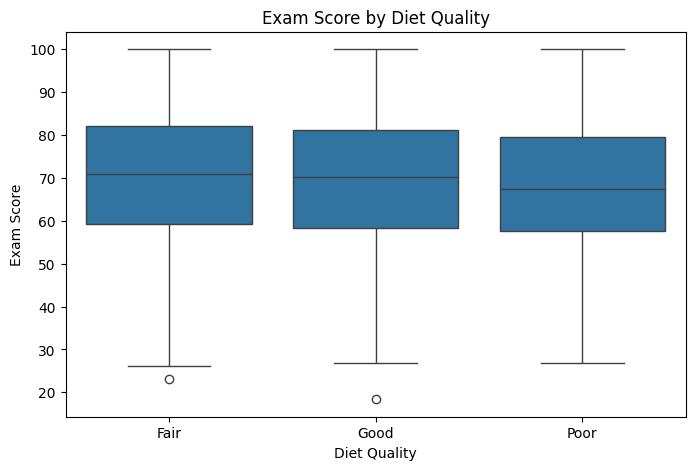

'\nExam score distributions across diet quality groups were relatively similar, with no strong difference in their median scores. This suggests that diet quality does not show a strong apparent relationship with exam performance in this dataset.\n'

In [78]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='diet_quality',
    y='exam_score'
)

plt.title('Exam Score by Diet Quality')
plt.xlabel('Diet Quality')
plt.ylabel('Exam Score')
plt.show()

"""
Exam score distributions across diet quality groups were relatively similar, with no strong difference in their median scores,
This suggests that diet quality does not show a strong apparent relationship with exam performance in this dataset.
"""

**the relation between the gender and the exam score:**

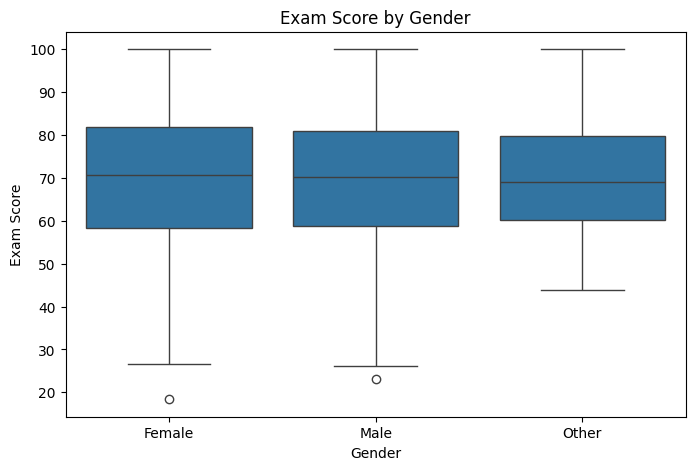

In [77]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='gender',
    y='exam_score'
)

plt.title('Exam Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Exam Score')
plt.show()

"""
Exam scores were relatively similar across gender groups,
with Male and Female students showing very close median scores.
The Other category also had a comparable distribution,
suggesting that gender does not have a strong apparent association with exam performance in this dataset.
"""

**the relation between the internet quality & the exam score:**

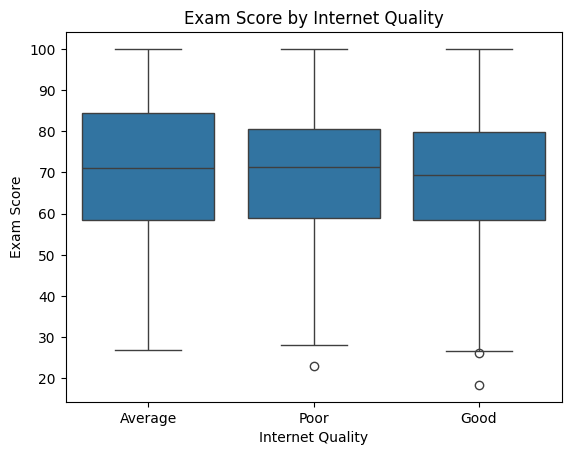

In [79]:
sns.boxplot(
    data=df,
    x='internet_quality',
    y='exam_score'
)

plt.title('Exam Score by Internet Quality')
plt.xlabel('Internet Quality')
plt.ylabel('Exam Score')
plt.show()

"""
Students with good internet quality had the lowest median exam score,
while students with average and poor internet quality had very similar median scores.
The Good category also had the smallest IQR, indicating less variability in exam scores within this group. Overall,
internet quality does not show the expected positive relationship with exam performance in this dataset.
"""

**Relation between Parental Education Level & exam score:**

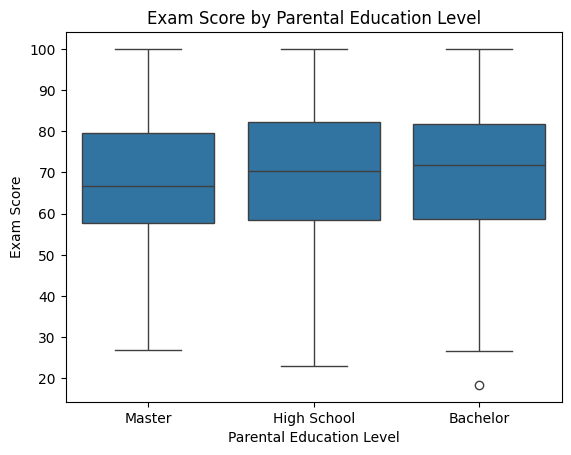

In [80]:
sns.boxplot(
    data=df,
    x='parental_education_level',
    y='exam_score'
)

plt.title('Exam Score by Parental Education Level')
plt.xlabel('Parental Education Level')
plt.ylabel('Exam Score')
plt.show()
"""

"""

#**Correlation matrix:**

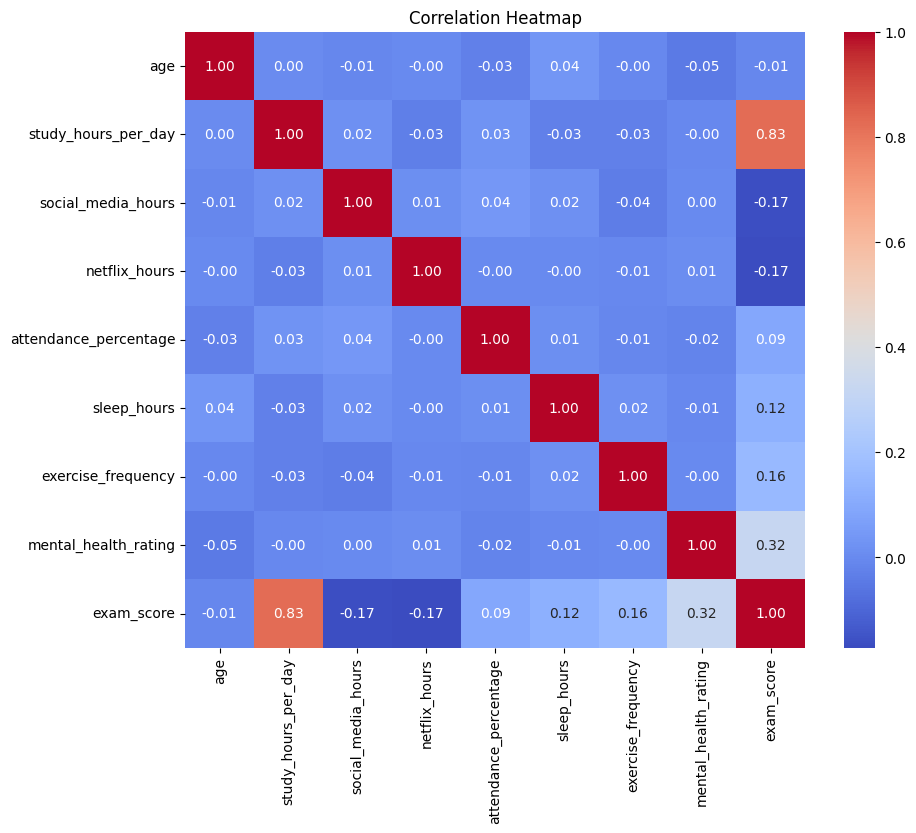

In [95]:
numeric_df = df.select_dtypes(include='number')

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [97]:
correlations = (
    df.select_dtypes(include='number')
      .corr()['exam_score']
      .sort_values(ascending=False)
)

correlations

,exam_score
exam_score,1.000000
study_hours_per_day,0.825419
mental_health_rating,0.321523
exercise_frequency,0.160107
sleep_hours,0.121683
attendance_percentage,0.089836
age,-0.008907
social_media_hours,-0.166733
netflix_hours,-0.171779


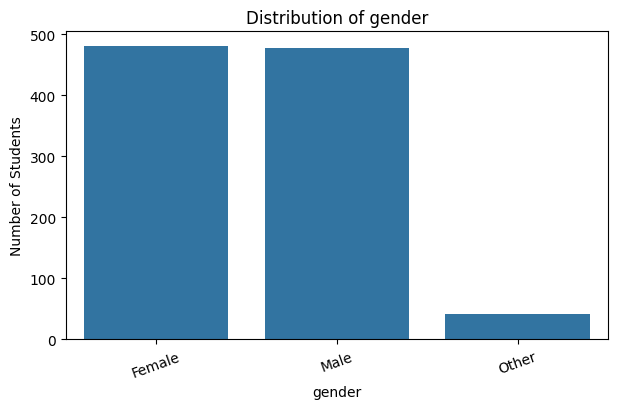

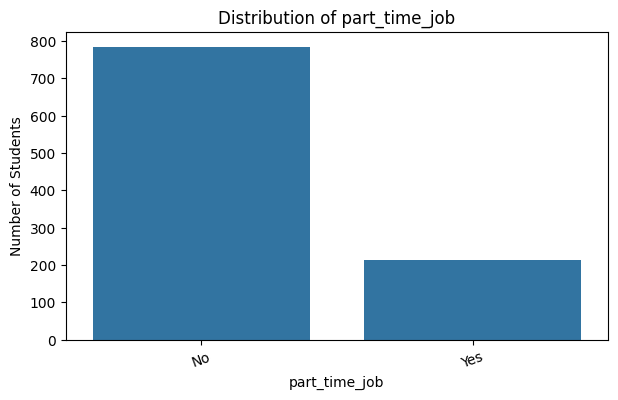

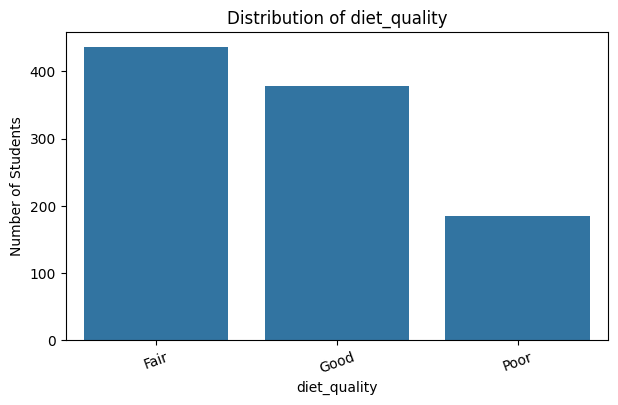

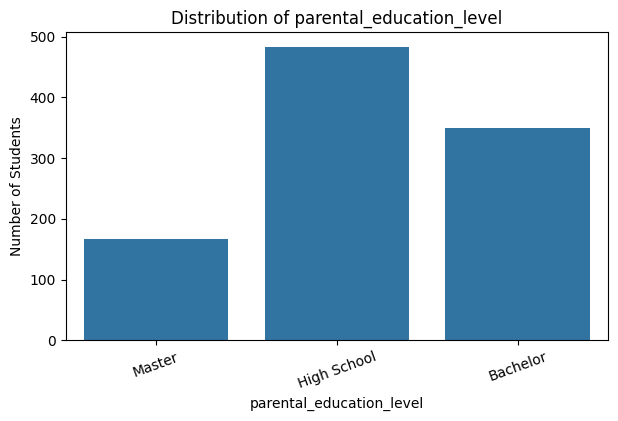

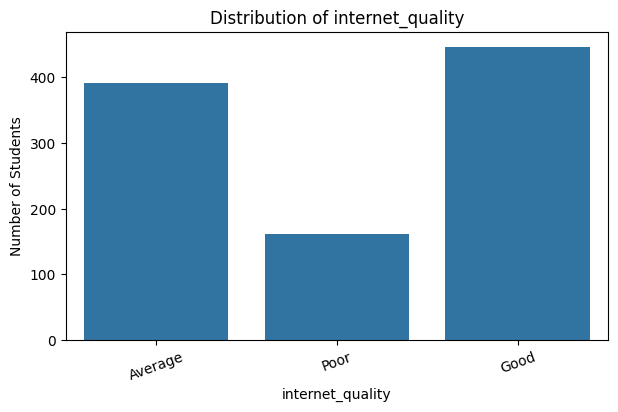

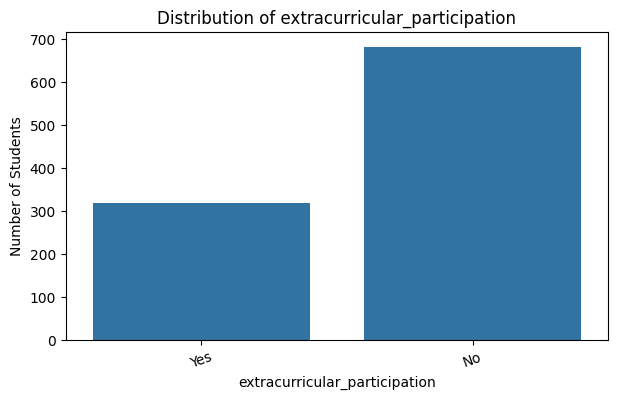

In [96]:
categorical_columns = [
    'gender',
    'part_time_job',
    'diet_quality',
    'parental_education_level',
    'internet_quality',
    'extracurricular_participation'
]

for col in categorical_columns:
    plt.figure(figsize=(7, 4))

    sns.countplot(
        data=df,
        x=col
    )

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Number of Students')
    plt.xticks(rotation=20)

    plt.show()